<a href="https://colab.research.google.com/github/anastasiatam/Engineering-with-Machine-Learning/blob/main/homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anastasia Tam

662031977

Engineering with Machine Learning

Homework 3

# **Question 1**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
from google.colab import files

# upload file
uploaded = files.upload()

Saving aircraft_performance.csv to aircraft_performance.csv


In [3]:
# Load Dataset
aircraft_data = pd.read_csv('aircraft_performance.csv')

# Extract features and scale
features = ['Speed_kmh', 'FuelFlow_kgph']
X = aircraft_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

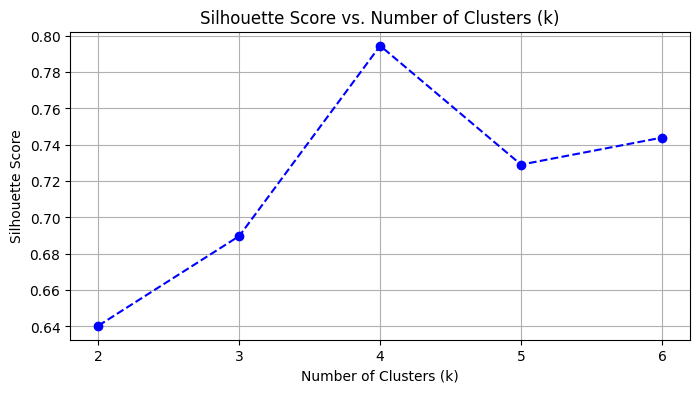

In [4]:
# Silhouette Analysis (k from 2 to 6)
k_values = list(range(2, 7))
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores vs k
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [5]:
# Fit K-Means with Optimal k
optimal_k = k_values[np.argmax(silhouette_scores)]
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
aircraft_data['Cluster'] = kmeans_final.fit_predict(X_scaled)

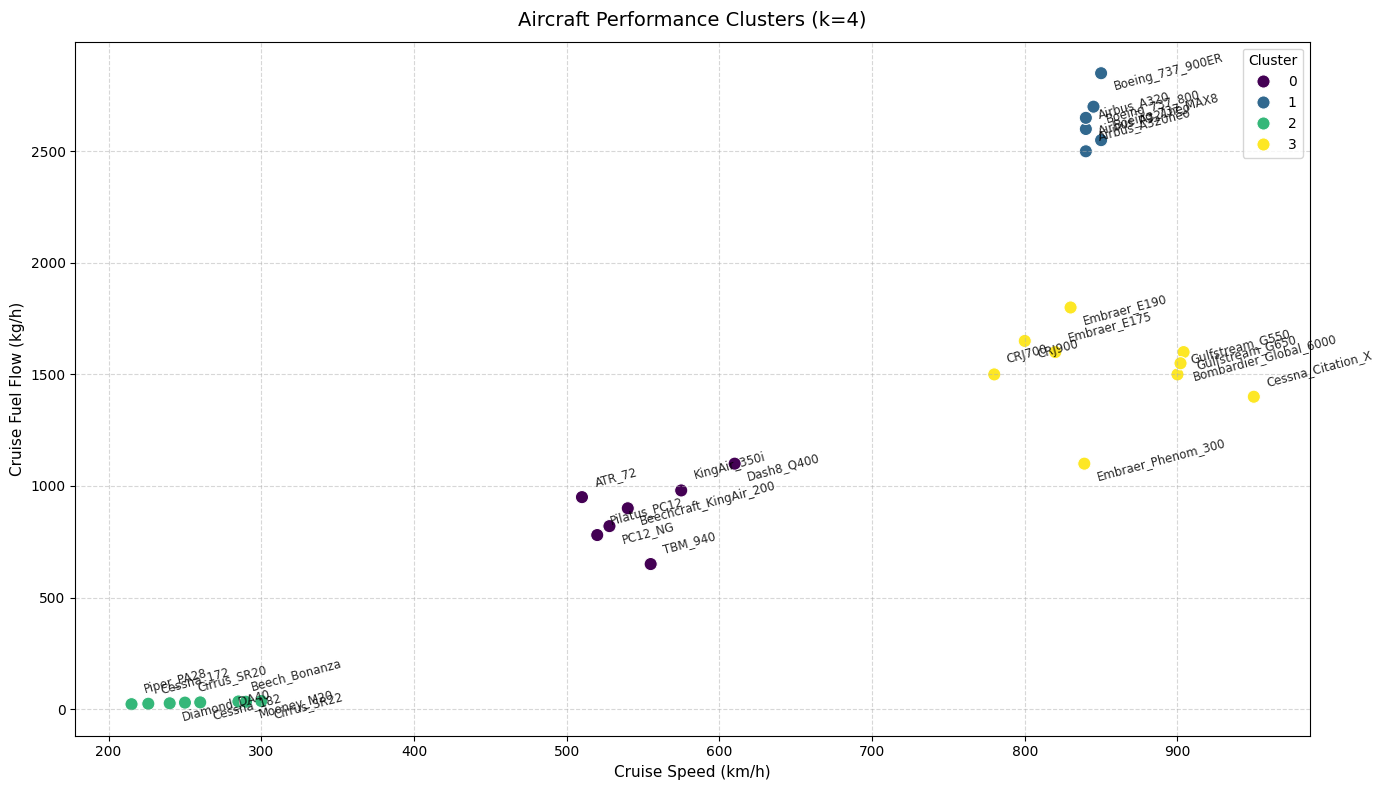

In [6]:
# Scatter plot
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=aircraft_data,
    x='Speed_kmh',
    y='FuelFlow_kgph',
    hue='Cluster',
    palette='viridis',
    s=90,
)

# Labels
for i, (name, x, y) in enumerate(
    zip(aircraft_data['Aircraft'], aircraft_data['Speed_kmh'], aircraft_data['FuelFlow_kgph'])
):

  y_offset = 8 if i % 2 == 0 else -12

  plt.annotate(
      text=str(name),
      xy=(x, y),
      xytext=(8, y_offset),
      textcoords='offset points',
      fontsize=8.5,
      rotation=15,
      alpha=0.85,
  )

plt.title(f'Aircraft Performance Clusters (k={optimal_k})', fontsize=14, pad=12)
plt.xlabel('Cruise Speed (km/h)', fontsize=11)
plt.ylabel('Cruise Fuel Flow (kg/h)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Green Cluster (Low Speed, Low Fuel Flow): Small propeller planes like the Beechcraft Bonanza and Piper PA-28 are built for short, budget-friendly trips. They fly slow using small engines, which keeps their fuel use super low.

Purple Cluster (Medium Speed, Medium Fuel Flow): Turboprops like the ATR 72 and TBM 940 are built for regional flights. They use jet-powered propellers to fly faster than basic planes while still saving fuel compared to pure jets.

Yellow Cluster (High Speed, Medium Fuel Flow): Business and regional jets like the Embraer E190 and Gulfstream G550 fly fast at high altitudes. The thin air high up reduces drag, letting them travel fast without using too much fuel.

Blue Cluster (High Speed, High Fuel Flow): Big passenger jets like the Boeing 737-900ER and Airbus A320 are built to carry hundreds of people at high speeds. Because they are so heavy, their powerful engines burn the most fuel per hour.

# **Question 2**

In [8]:
# load file
uploaded = files.upload()

Saving housing_prices.txt to housing_prices (1).txt


In [10]:
# Load housing_prices.txt
housing_data = pd.read_csv('housing_prices.txt', header=None, names=['Population', 'Price'])
X_pop = housing_data['Population'].values
y_price = housing_data['Price'].values
m = len(y_price)

In [13]:
# Feature Scaling / Normalization (essential for stable gradient descent)
X_mean, X_std = np.mean(X_pop), np.std(X_pop)
X_pop_scaled = (X_pop - X_mean) / X_std

# Intercept term (column of 1s for theta_0)
X_b = np.c_[np.ones((m, 1)), X_pop_scaled]

In [32]:
# Mini-Batch Gradient Descent Function
def mini_batch_gradient_descent(X, y, batch_size, lr, epochs):
  m, n = X.shape
  np.random.seed(42)
  theta = np.zeros(n)  # Initialize weights [theta_0, theta_1]
  cost_history = []

  for epoch in range(epochs):
    # Shuffle data each epoch
    indices = np.random.permutation(m)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, m, batch_size):
      X_batch = X_shuffled[i : i + batch_size]
      y_batch = y_shuffled[i : i + batch_size]

      # Compute predictions and gradients
      predictions = X_batch.dot(theta)
      errors = predictions - y_batch
      gradients = (1 / len(y_batch)) * X_batch.T.dot(errors)

      # Update weights
      theta -= lr * gradients

      # Calculate and store cost
      full_predictions = X.dot(theta)
      cost = (1 / (2 * m)) * np.sum((full_predictions - y) ** 2)
      cost_history.append(cost)

  return theta, cost_history

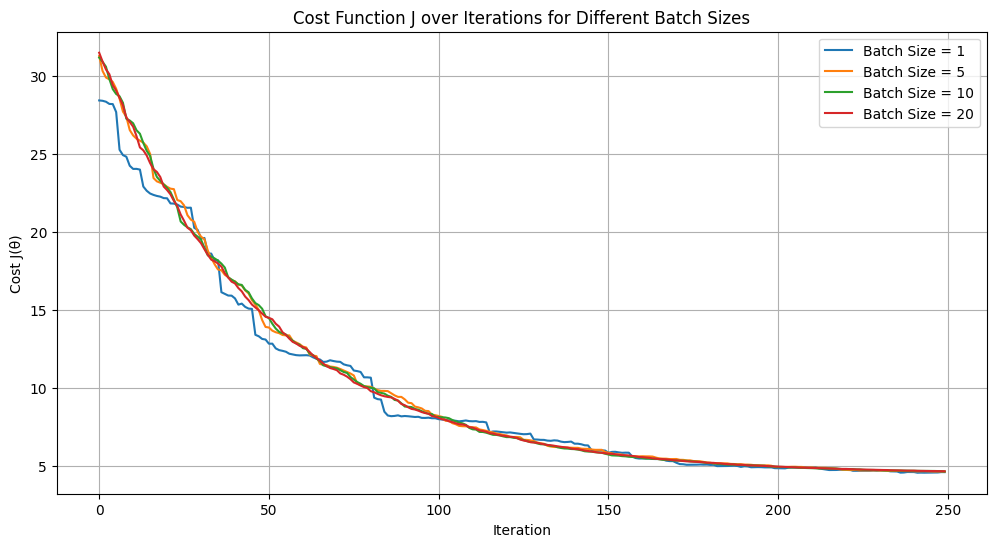

In [47]:
# Run batch sizes
batch_sizes = [1, 5, 10, 20]
results = {}

plt.figure(figsize=(12, 6))

for b in batch_sizes:
  theta, cost_history = mini_batch_gradient_descent(
      X_b, y_price, batch_size=b, lr=0.01, epochs=70
  )
  results[b] = theta
  plt.plot(cost_history[:250], label=f'Batch Size = {b}')

plt.title('Cost Function J over Iterations for Different Batch Sizes')
plt.xlabel('Iteration')
plt.ylabel('Cost J(θ)')
plt.legend()
plt.grid(True)
plt.show()

Batch size of 1 produces a jagged, noisy line that varies up and down.

In [51]:
# Predict for Population = 160,000 (X_input = 16.0)
pop_input = 16.0
pop_scaled = (pop_input - X_mean) / X_std
x_predict = np.array([1, pop_scaled])

print("\n--- Predictions for City Population of 160,000 ---")
for b in batch_sizes:
  theta = results[b]
  predicted_val = x_predict.dot(theta)
  actual_price = predicted_val * 10000  # Convert back from 10k units
  print(f"Batch Size {b:2d}: ${actual_price:,.2f}")


--- Predictions for City Population of 160,000 ---
Batch Size  1: $151,940.56
Batch Size  5: $151,956.19
Batch Size 10: $151,866.99
Batch Size 20: $147,423.51


# **Question 3**

In [52]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [53]:
# Load Dataset
bc_data = load_breast_cancer()
X_bc = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
y_bc = bc_data.target  # 0 = Malignant, 1 = Benign

In [54]:
# Train-Test Split (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.30, random_state=42, stratify=y_bc
)

In [55]:
# Feature Scaling (Crucial for Logistic Regression & RFE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
# Recursive Feature Elimination (RFE) to select top 2 features
base_model = LogisticRegression(random_state=42, max_iter=10000)
rfe = RFE(estimator=base_model, n_features_to_select=2)
rfe.fit(X_train_scaled, y_train)

# Identify selected features
selected_feature_indices = np.where(rfe.support_)[0]
selected_features = X_bc.columns[selected_feature_indices].tolist()

print("--- Feature Selection Results ---")
print(f"Top 2 Selected Features: {selected_features}\n")

# Transform datasets to include only selected features
X_train_selected = rfe.transform(X_train_scaled)
X_test_selected = rfe.transform(X_test_scaled)

--- Feature Selection Results ---
Top 2 Selected Features: ['worst area', 'worst concave points']



In [64]:
# Train Final Model on Selected Features
final_model = LogisticRegression(random_state=42)
final_model.fit(X_train_selected, y_train)

# Evaluation on Test Set
y_pred = final_model.predict(X_test_selected)
y_proba = final_model.predict_proba(X_test_selected)[:, 1]

print("--- Model Evaluation Metrics (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")

--- Model Evaluation Metrics (Test Set) ---
Accuracy:  0.9415
Precision: 0.9450
Recall:    0.9626
F1 Score:  0.9537
ROC AUC:   0.9777



In [65]:
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (Malignant correctly identified): {cm[0, 0]}")
print(f"False Positives (Malignant misclassified as Benign): {cm[0, 1]}")
print(f"False Negatives (Benign misclassified as Malignant): {cm[1, 0]}")
print(f"True Positives (Benign correctly identified): {cm[1, 1]}\n")

print("--- Detailed Classification Report ---")
print(
    classification_report(
        y_test, y_pred, target_names=bc_data.target_names, digits=4
    )
)

--- Confusion Matrix ---
True Negatives (Malignant correctly identified): 58
False Positives (Malignant misclassified as Benign): 6
False Negatives (Benign misclassified as Malignant): 4
True Positives (Benign correctly identified): 103

--- Detailed Classification Report ---
              precision    recall  f1-score   support

   malignant     0.9355    0.9062    0.9206        64
      benign     0.9450    0.9626    0.9537       107

    accuracy                         0.9415       171
   macro avg     0.9402    0.9344    0.9372       171
weighted avg     0.9414    0.9415    0.9413       171



# **Question 4**


In [66]:
import tensorflow as tf
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [72]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# load file
uploaded = files.upload()

Saving housing_prices.txt to housing_prices (2).txt


In [73]:
# Load dataset
tf_nn_data = pd.read_csv('housing_prices.txt', header=None, names=['Population', 'Price'])
X_tf_raw = tf_nn_data['Population'].values.reshape(-1, 1)
y_tf_raw = tf_nn_data['Price'].values

# Train-Validation Split (70% Train, 30% Validation)
X_tf_train_raw, X_tf_val_raw, y_tf_train, y_tf_val = train_test_split(
    X_tf_raw, y_tf_raw, test_size=0.30, random_state=42
)

# Standardize Features
tf_scaler = StandardScaler()
X_tf_train = tf_scaler.fit_transform(X_tf_train_raw)
X_tf_val = tf_scaler.transform(X_tf_val_raw)

In [146]:
# Build Neural Network Architecture
# Architecture: Input (1) -> Hidden Layer (2 neurons, ReLU) -> Output (1 neuron, Linear)
tf_nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        units=2, activation='relu', input_shape=(1,), name='hidden_layer_relu'
    ),
    tf.keras.layers.Dense(units=1, activation='linear', name='output_layer'),
])

# Compile Model with SGD and Mean Squared Error Loss
tf_learning_rate = 0.001
tf_sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=tf_learning_rate)

tf_nn_model.compile(optimizer=tf_sgd_optimizer, loss='mse', metrics=['mse'])

# Display Neural Network Structure
tf_nn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_relu (Dense)       │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [147]:
# Fit Model
tf_epochs = 100
tf_history = tf_nn_model.fit(
    X_tf_train,
    y_tf_train,
    validation_data=(X_tf_val, y_tf_val),
    epochs=tf_epochs,
    batch_size=1,  # SGD updates per sample
    verbose=0,  # Suppress long epoch log prints
)

In [148]:
# Evaluate Model with Useful Regression Metrics
y_tf_val_pred = tf_nn_model.predict(X_tf_val)
tf_val_mse = mean_squared_error(y_tf_val, y_tf_val_pred)
tf_val_rmse = np.sqrt(tf_val_mse)
tf_val_r2 = r2_score(y_tf_val, y_tf_val_pred)

print("\n=== Neural Network Performance (Validation Set) ===")
print(f"Mean Squared Error (MSE): {tf_val_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): ${tf_val_rmse * 10000:,.2f}")
print(f"R² Score (Variance Explained): {tf_val_r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

=== Neural Network Performance (Validation Set) ===
Mean Squared Error (MSE): 11.7634
Root Mean Squared Error (RMSE): $34,297.88
R² Score (Variance Explained): 0.5725


In [149]:
# Predict Price for Population = 165,000 (X = 16.5)
target_pop = np.array([[16.5]])
target_pop_scaled = tf_scaler.transform(target_pop)
tf_nn_pred = tf_nn_model.predict(target_pop_scaled)
predicted_price = tf_nn_pred[0][0] * 10000

print("\n=== Prediction Result ===")
print(
    f"Predicted House Price for Population 165,000: ${predicted_price:,.2f}"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

=== Prediction Result ===
Predicted House Price for Population 165,000: $168,538.89


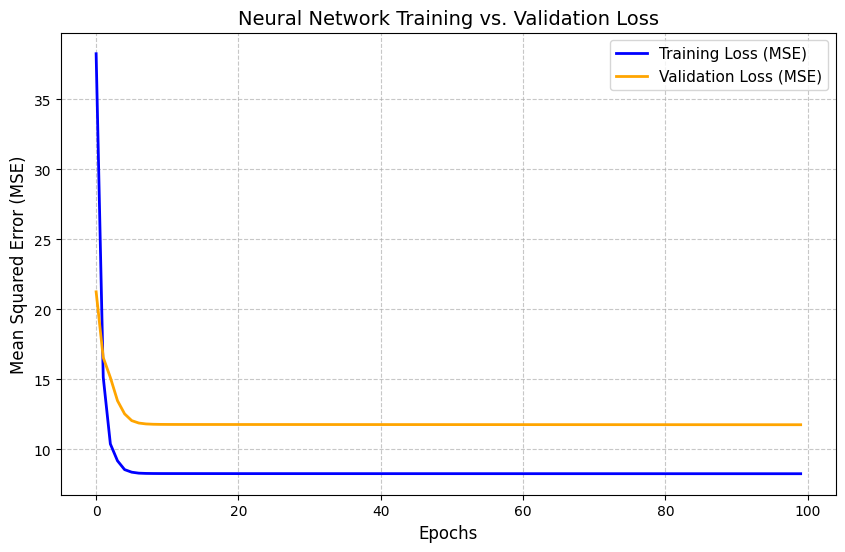

In [150]:
# Plot Training vs Validation Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(
    tf_history.history['loss'],
    label='Training Loss (MSE)',
    color='blue',
    linewidth=2,
)
plt.plot(
    tf_history.history['val_loss'],
    label='Validation Loss (MSE)',
    color='orange',
    linewidth=2,
)
plt.title(
    'Neural Network Training vs. Validation Loss', fontsize=14
)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

When the training starts, the model's guess is pure randomness, so the error (MSE) is high at around 40 to 50.

Because the data is scaled, the model quickly figures out the general direction of the line within the first 3 epochs, causing the error to drop instantly to around 10.

After that, it flattens out because a simple model with 2 neurons has hit its limit; an MSE of around 10 is the lowest error possible for this dataset. The small 0.001 learning rate keeps everything smooth, stopping the error from bouncing around for the rest of the epochs.

The training and validation loss curves follow nearly identical paths throughout training. This close alignment proves that the model generalizes well to new data and is neither overfitting nor underfitting.


**END OF HOMEWORK**